# Kathmandu Valley Rental Price Estimation — Refined Notebook

## Goal

Build a machine-learning model that estimates **monthly residential rent in NPR** for properties in Kathmandu Valley.

### Important working rule

This notebook is a **clean rebuild/refinement** based on the existing `main.ipynb`.

We will **not copy every old cell blindly**. We will inspect each part, understand why it exists, decide whether it is correct, and then rebuild only the useful parts.

### Learning approach

For every major step:

1. Understand what the old project did.
2. Check whether the decision is correct.
3. Decide **KEEP / CHANGE / REMOVE**.
4. Learn the ML/data-science concept.
5. Write the clean version.
6. Only then move to the next step.

### Current known dataset state

The current modeling dataframe from the original notebook has:

- **151 rows**
- **19 columns**
- Kathmandu: 117 listings
- Bhaktapur: 33 listings
- Lalitpur: 1 listing
- `district` has already been removed.

The original project also contains a scraper and an earlier cleaning notebook.

> **Do not train a model in this notebook yet.**
> First we will make sure the data is correct and understand every feature.


## Stage 1 — Load and inspect the data

Before cleaning anything, we need to know exactly what we are working with.

We will first inspect:

- shape
- column names
- data types
- missing values
- target distribution
- categorical values

We will **not modify the dataframe in these first cells**.

In [2]:
import pandas as pd
import numpy as np

# Update this path/name if your current CSV has a different filename.
DATA_PATH = "nepal_rental_kathmandu_dataset.csv"

data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
data.head()

Shape: (156, 24)


,listing_id,title,monthly_rent_npr,area_sqft_approx,road_width_ft,location,ward,municipality,district,property_type,...,living_rooms,kitchens,total_rooms,parking,built_up_sqft,no_of_flats,built_year,description,city,source
0,9541,House for rent,75000.0,1197.88,14.0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",26.0,Kathmandu Metropolis,Kathmandu,house,...,3.0,2.0,8.0,Car 1,2200.0,2.5,2072,Prime location. Posh area.,kathmandu,gharghaderi.com
1,9464,"House on rent: Civil Homes Phase VII, Nagarjun-6",50000.0,1026.75,10.0,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",6.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 3-5,850.0,2.0,2075,A well-maintained house on 2.5 anna land is av...,kathmandu,gharghaderi.com
2,9361,4 BHK Semi Furnished House for Rent at Bhaisepati,119999.0,1540.12,12.0,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",18.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 2,1600.0,2.5,2070,4BHK Semi Furninsed house on rent at Bhaisepat...,kathmandu,gharghaderi.com
3,9087,House on Rent at Koteswor for Office or Restau...,250000.0,3935.88,26.0,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",32.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,9.0,Cars 5-10,3100.0,2.5,2065,NaN,kathmandu,gharghaderi.com
4,9034,Fully-Furnished House on rent at Budhanilkantha,120000.0,1369.00,13.0,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",NaN,Budhanilkantha Kathmandu Metropolis,Kathmandu,house,...,2.0,1.0,NaN,Car 1,NaN,NaN,Select Year,Fully-Furnished House on rent at Budhanilkanth...,kathmandu,gharghaderi.com


In [6]:
# 1. What columns do we currently have?
data.columns.tolist()

['listing_id',
 'title',
 'monthly_rent_npr',
 'area_sqft_approx',
 'road_width_ft',
 'location',
 'ward',
 'municipality',
 'district',
 'property_type',
 'house_type',
 'direction',
 'bedrooms',
 'bathrooms',
 'living_rooms',
 'kitchens',
 'total_rooms',
 'parking',
 'built_up_sqft',
 'no_of_flats',
 'built_year',
 'description',
 'city',
 'source']

In [8]:
# 2. What type of data is in each column?
data.dtypes

listing_id            int64
title                   str
monthly_rent_npr    float64
area_sqft_approx    float64
road_width_ft       float64
location                str
ward                float64
municipality            str
district                str
property_type           str
house_type              str
direction               str
bedrooms            float64
bathrooms           float64
living_rooms        float64
kitchens            float64
total_rooms         float64
parking                 str
built_up_sqft       float64
no_of_flats         float64
built_year              str
description             str
city                    str
source                  str
dtype: object

In [10]:
# 3. How much missing data is there?
missing = (
    data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

built_up_sqft       127
total_rooms         126
ward                 75
living_rooms         67
municipality         62
area_sqft_approx     39
house_type           38
kitchens             35
no_of_flats          34
road_width_ft        28
parking              23
description          12
bedrooms              8
bathrooms             3
title                 0
monthly_rent_npr      0
location              0
listing_id            0
direction             0
district              0
property_type         0
built_year            0
city                  0
source                0
dtype: int64

In [12]:
# 4. Basic information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        156 non-null    int64  
 1   title             156 non-null    str    
 2   monthly_rent_npr  156 non-null    float64
 3   area_sqft_approx  117 non-null    float64
 4   road_width_ft     128 non-null    float64
 5   location          156 non-null    str    
 6   ward              81 non-null     float64
 7   municipality      94 non-null     str    
 8   district          156 non-null    str    
 9   property_type     156 non-null    str    
 10  house_type        118 non-null    str    
 11  direction         156 non-null    str    
 12  bedrooms          148 non-null    float64
 13  bathrooms         153 non-null    float64
 14  living_rooms      89 non-null     float64
 15  kitchens          121 non-null    float64
 16  total_rooms       30 non-null     float64
 17  parking 

## Stage 1 checkpoint

After running the cells above, **stop**.

Do not drop columns, fill missing values, encode categories, scale data, or train a model yet.

We will review the output together and classify every column as:

- 🟢 **KEEP**
- 🟡 **CLEAN / TRANSFORM**
- 🔴 **REMOVE**

Only after that will we write the cleaning code.

## Previous model results — reference only

The original notebook already trained several regression models.

The strongest recorded untuned Random Forest result was approximately:

- **MAE:** NPR 46,974
- **R²:** 0.449

A tuned Random Forest performed worse, so we will **not assume that tuning automatically improves the model**.

These results are kept here only as a reference. We will build the final model again after fixing and understanding the data.

In [ ]:
# inspect data 

In [14]:
for col in [
    "property_type",
    "house_type",
    "direction",
    "parking",
    "built_year",
    "municipality"
]:
    print(f"\n{'='*50}")
    print(col)
    print(data[col].value_counts(dropna=False))
    print("WARD VALUES")
    print(sorted(data["ward"].dropna().unique()))
    print("NUMBER OF UNIQUE LOCATIONS:", data["location"].nunique())

    print("\nLOCATION VALUES:")
    print(data["location"].value_counts().head(30))


property_type
property_type
house         83
apartments    39
flats         34
Name: count, dtype: int64
WARD VALUES
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(18.0), np.float64(26.0), np.float64(28.0), np.float64(32.0), np.float64(34.0)]
NUMBER OF UNIQUE LOCATIONS: 125

LOCATION VALUES:
location
Baluwatar Kathmandu Metropolis Kathmandu, Bagmati          6
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati         4
budhanilkantha Budhanilkantha Kathmandu, Bagmati           4
Baneshwor Kathmandu Metropolis Kathmandu, Bagmati          4
Lazimpath Kathmandu Metropolis Kathmandu, Bagmati          4
Maharajgunj Kathmandu Metropolis Kathmandu, Bagmati        3
Tokha Kathmandu Metropolis Kathmandu, Bagmati              3
Sitapaila 6 Kathmandu Metropolis Kathmandu, 

In [16]:
df = data.copy()

In [20]:
print("CITY")
print(df["city"].value_counts(dropna=False))

print("\nDISTRICT")
print(df["district"].value_counts(dropna=False))

print("\nMUNICIPALITY")
print(df["municipality"].value_counts(dropna=False))



CITY
city
kathmandu    122
bhaktapur     33
lalitpur       1
Name: count, dtype: int64

DISTRICT
district
Kathmandu    156
Name: count, dtype: int64

MUNICIPALITY
municipality
NaN                                               62
Kathmandu Metropolis                              39
Baluwatar Kathmandu Metropolis                     6
Baneshwor Kathmandu Metropolis                     5
Dhumbarahi Kathmandu Metropolis                    4
Lazimpath Kathmandu Metropolis                     4
Maharajgunj Kathmandu Metropolis                   3
Tokha Kathmandu Metropolis                         3
Budhanilkantha Kathmandu Metropolis                2
Maitinagar Kathmandu Metropolis                    1
Imadol Kathmandu Metropolis                        1
Kalanki Kathmandu Metropolis                       1
Sano bharyang Kathmandu Metropolis                 1
chappalkarkhana Kathmandu Metropolis               1
mid baneshwor Kathmandu Metropolis                 1
Budhanilkanth Kathmandu Metro

In [22]:
pd.crosstab(
    df["city"],
    df["district"],
    dropna=False
)

district,Kathmandu
city,
bhaktapur,33
kathmandu,122
lalitpur,1


In [24]:
df[df["city"].str.contains("pokhara", case=False, na=False)]

,listing_id,title,monthly_rent_npr,area_sqft_approx,road_width_ft,location,ward,municipality,district,property_type,...,living_rooms,kitchens,total_rooms,parking,built_up_sqft,no_of_flats,built_year,description,city,source


In [26]:
df.loc[
    df["city"].str.contains("pokhara", case=False, na=False),
    ["listing_id", "city", "district", "municipality", "location", "monthly_rent_npr"]
]

,listing_id,city,district,municipality,location,monthly_rent_npr


In [28]:
print("Number of unique locations:", df["location"].nunique())

print("\nTop 30 locations:")
print(df["location"].value_counts(dropna=False).head(30))

Number of unique locations: 125

Top 30 locations:
location
Baluwatar Kathmandu Metropolis Kathmandu, Bagmati          6
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati         4
budhanilkantha Budhanilkantha Kathmandu, Bagmati           4
Baneshwor Kathmandu Metropolis Kathmandu, Bagmati          4
Lazimpath Kathmandu Metropolis Kathmandu, Bagmati          4
Maharajgunj Kathmandu Metropolis Kathmandu, Bagmati        3
Tokha Kathmandu Metropolis Kathmandu, Bagmati              3
Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati        2
Budhanilkantha Kathmandu Metropolis Kathmandu, Bagmati     2
Mandikatar Budhanilkantha Kathmandu, Bagmati               2
Chobhar Kirtipur Kathmandu, Bagmati                        2
Maharajgunj 3 Kathmandu Metropolis Kathmandu, Bagmati      2
tahachal 13 Kathmandu Kathmandu, Bagmati                   2
Baluwatar 4 Kathmandu Metropolis Kathmandu, State 3        2
Boudha 6 Kathmandu Metropolis Kathmandu, Bagmati           2
Tokha Budhanilkantha Kath

In [30]:
location_city = (
    df.groupby(["city", "location"], dropna=False)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

location_city.head(50)

,city,location,count
34,kathmandu,"Baluwatar Kathmandu Metropolis Kathmandu, Bagmati",6
36,kathmandu,"Baneshwor Kathmandu Metropolis Kathmandu, Bagmati",4
72,kathmandu,"Lazimpath Kathmandu Metropolis Kathmandu, Bagmati",4
110,kathmandu,"budhanilkantha Budhanilkantha Kathmandu, Bagmati",4
104,kathmandu,"Tokha Kathmandu Metropolis Kathmandu, Bagmati",3
75,kathmandu,"Maharajgunj Kathmandu Metropolis Kathmandu, Ba...",3
53,kathmandu,"Dhumbarahi Kathmandu Metropolis Kathmandu, Bag...",3
45,kathmandu,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",2
71,kathmandu,"Lazimpath 8 Kathmandu Metropolis Kathmandu, Ba...",2
103,kathmandu,"Tokha Budhanilkantha Kathmandu, Bagmati",2


In [32]:
municipality_city = (
    df.groupby(["city", "municipality"], dropna=False)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

municipality_city

,city,municipality,count
38,kathmandu,NaN,47
17,kathmandu,Kathmandu Metropolis,23
1,bhaktapur,Kathmandu Metropolis,16
3,bhaktapur,NaN,15
4,kathmandu,Baluwatar Kathmandu Metropolis,6
6,kathmandu,Baneshwor Kathmandu Metropolis,5
19,kathmandu,Lazimpath Kathmandu Metropolis,4
12,kathmandu,Dhumbarahi Kathmandu Metropolis,3
32,kathmandu,Tokha Kathmandu Metropolis,3
20,kathmandu,Maharajgunj Kathmandu Metropolis,3


In [34]:
print("Missing ward:", df["ward"].isna().sum())
print("Non-missing ward:", df["ward"].notna().sum())

print("\nWard values:")
print(sorted(df["ward"].dropna().unique()))

Missing ward: 75
Non-missing ward: 81

Ward values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(18.0), np.float64(26.0), np.float64(28.0), np.float64(32.0), np.float64(34.0)]


In [36]:
print(df["city"].value_counts(dropna=False))

city
kathmandu    122
bhaktapur     33
lalitpur       1
Name: count, dtype: int64


In [40]:
df["city"] = df["city"].astype("string").str.strip().str.title()


In [42]:
print(df["city"].value_counts(dropna=False))

city
Kathmandu    122
Bhaktapur     33
Lalitpur       1
Name: count, dtype: Int64


In [44]:
df = df.drop(columns=["district"])

In [46]:
print(df.columns.tolist())
    

['listing_id', 'title', 'monthly_rent_npr', 'area_sqft_approx', 'road_width_ft', 'location', 'ward', 'municipality', 'property_type', 'house_type', 'direction', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'total_rooms', 'parking', 'built_up_sqft', 'no_of_flats', 'built_year', 'description', 'city', 'source']


In [48]:
print("Number of unique locations:", df["location"].nunique())
print(df["location"].value_counts(dropna=False).head(30))

Number of unique locations: 125
location
Baluwatar Kathmandu Metropolis Kathmandu, Bagmati          6
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati         4
budhanilkantha Budhanilkantha Kathmandu, Bagmati           4
Baneshwor Kathmandu Metropolis Kathmandu, Bagmati          4
Lazimpath Kathmandu Metropolis Kathmandu, Bagmati          4
Maharajgunj Kathmandu Metropolis Kathmandu, Bagmati        3
Tokha Kathmandu Metropolis Kathmandu, Bagmati              3
Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati        2
Budhanilkantha Kathmandu Metropolis Kathmandu, Bagmati     2
Mandikatar Budhanilkantha Kathmandu, Bagmati               2
Chobhar Kirtipur Kathmandu, Bagmati                        2
Maharajgunj 3 Kathmandu Metropolis Kathmandu, Bagmati      2
tahachal 13 Kathmandu Kathmandu, Bagmati                   2
Baluwatar 4 Kathmandu Metropolis Kathmandu, State 3        2
Boudha 6 Kathmandu Metropolis Kathmandu, Bagmati           2
Tokha Budhanilkantha Kathmandu, Bagmati     

In [50]:
location_city

,city,location,count
34,kathmandu,"Baluwatar Kathmandu Metropolis Kathmandu, Bagmati",6
36,kathmandu,"Baneshwor Kathmandu Metropolis Kathmandu, Bagmati",4
72,kathmandu,"Lazimpath Kathmandu Metropolis Kathmandu, Bagmati",4
110,kathmandu,"budhanilkantha Budhanilkantha Kathmandu, Bagmati",4
104,kathmandu,"Tokha Kathmandu Metropolis Kathmandu, Bagmati",3
...,...,...,...
122,kathmandu,sundarbasti (valley public school) 8 Budhanilk...,1
123,kathmandu,"swayambhu Nagarjun Kathmandu, Bagmati",1
124,kathmandu,"tarksewor 04 Kathmandu Metropolis Kathmandu, S...",1
125,kathmandu,"tokha 3 Tokha Kathmandu, Bagmati",1


In [52]:
municipality_city

,city,municipality,count
38,kathmandu,NaN,47
17,kathmandu,Kathmandu Metropolis,23
1,bhaktapur,Kathmandu Metropolis,16
3,bhaktapur,NaN,15
4,kathmandu,Baluwatar Kathmandu Metropolis,6
6,kathmandu,Baneshwor Kathmandu Metropolis,5
19,kathmandu,Lazimpath Kathmandu Metropolis,4
12,kathmandu,Dhumbarahi Kathmandu Metropolis,3
32,kathmandu,Tokha Kathmandu Metropolis,3
20,kathmandu,Maharajgunj Kathmandu Metropolis,3


In [54]:
sorted(df["ward"].dropna().unique())

[np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(18.0),
 np.float64(26.0),
 np.float64(28.0),
 np.float64(32.0),
 np.float64(34.0)]

In [56]:
# backup plus lowercase
df["location_raw"] = df["location"]

df["location"] = (
    df["location"]
    .astype("string")
    .str.strip()
    .str.lower()
)

print("Unique locations before:", df["location_raw"].nunique())
print("Unique locations after:", df["location"].nunique())

Unique locations before: 125
Unique locations after: 123


In [58]:
# inspects spelling varaiants
df[df["location"].isin([
    "budhanilkanth",
    "budhanilkantha",
    "naxal",
    "naksal",
    "tahchal",
    "tahachal"
])][
    ["city", "location_raw", "location", "monthly_rent_npr"]
]

,city,location_raw,location,monthly_rent_npr


In [60]:
# inspect location containing numbers
numeric_locations = df[
    df["location"].str.contains(r"\d", na=False)
]

print(
    numeric_locations[
        ["city", "location_raw", "location", "ward"]
    ].to_string(index=False)
)

     city                                                             location_raw                                                                 location  ward
Kathmandu                     Samakhusi 26 Kathmandu Metropolis Kathmandu, Bagmati                     samakhusi 26 kathmandu metropolis kathmandu, bagmati  26.0
Kathmandu                      Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati                      sitapaila 6 kathmandu metropolis kathmandu, bagmati   6.0
Kathmandu                    Bhaisepati 18 Kathmandu Metropolis Kathmandu, Bagmati                    bhaisepati 18 kathmandu metropolis kathmandu, bagmati  18.0
Kathmandu                      Koteswor 32 Kathmandu Metropolis Kathmandu, Bagmati                      koteswor 32 kathmandu metropolis kathmandu, bagmati  32.0
Kathmandu                     Bansbari-3 3 Kathmandu Metropolis Kathmandu, Bagmati                     bansbari-3 3 kathmandu metropolis kathmandu, bagmati   3.0
Kathmandu                   

In [62]:
# inspect rare locations
location_counts = df["location"].value_counts(dropna=False)

print("Number of locations occurring once:",
      (location_counts == 1).sum())

print("\nLocations occurring once:")
print(location_counts[location_counts == 1])

Number of locations occurring once: 105

Locations occurring once:
location
bhaisepati 18 kathmandu metropolis kathmandu, bagmati             1
koteswor 32 kathmandu metropolis kathmandu, bagmati               1
bansbari-3 3 kathmandu metropolis kathmandu, bagmati              1
maitinagar kathmandu metropolis kathmandu, bagmati                1
imadol kathmandu metropolis kathmandu, bagmati                    1
                                                                 ..
kadaghari, pepsicola 9 kathmandu metropolis kathmandu, state 3    1
gyandeep marg, lazimpat 2 kathmandu kathmandu, state 3            1
galfutar budhanilkantha kathmandu, bagmati                        1
tarksewor 04 kathmandu metropolis kathmandu, state 3              1
goldunga 04 tarkeshwor kathmandu, bagmati                         1
Name: count, Length: 105, dtype: Int64


In [64]:
print(df["location_raw"].head(20).to_string(index=False))

Samakhusi 26 Kathmandu Metropolis Kathmandu, Ba...
Sitapaila 6 Kathmandu Metropolis Kathmandu, Bag...
Bhaisepati 18 Kathmandu Metropolis Kathmandu, B...
Koteswor 32 Kathmandu Metropolis Kathmandu, Bag...
Budhanilkantha Kathmandu Metropolis Kathmandu, ...
Bansbari-3 3 Kathmandu Metropolis Kathmandu, Ba...
Maitinagar Kathmandu Metropolis Kathmandu, Bagmati
    Imadol Kathmandu Metropolis Kathmandu, Bagmati
   Kalanki Kathmandu Metropolis Kathmandu, Bagmati
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
  budhanilkantha Budhanilkantha Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
        shyambhu Budhanilkantha Kathmandu, Bagmati
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati
Sano bharyang Kathmandu Metropolis Kathmandu, B...
      Hattigauda Budhanilkantha Kathmandu, Bagmati
     ganeshchowk Budhanilkantha Kathmandu, Bagmati
  budhanilkantha Budhanilkantha

In [66]:
print(df[[
    "city",
    "location_raw",
    "ward"
]].head(20).to_string(index=False))

     city                                           location_raw  ward
Kathmandu   Samakhusi 26 Kathmandu Metropolis Kathmandu, Bagmati  26.0
Kathmandu    Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati   6.0
Kathmandu  Bhaisepati 18 Kathmandu Metropolis Kathmandu, Bagmati  18.0
Kathmandu    Koteswor 32 Kathmandu Metropolis Kathmandu, Bagmati  32.0
Kathmandu Budhanilkantha Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu   Bansbari-3 3 Kathmandu Metropolis Kathmandu, Bagmati   3.0
Kathmandu     Maitinagar Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu         Imadol Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu        Kalanki Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu     Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu      Baluwatar Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu      Baluwatar Kathmandu Metropolis Kathmandu, Bagmati   NaN
Kathmandu       budhanilkantha Budhanilkantha Kathmandu, Bagmati   NaN
Kathma

In [68]:
numeric_locations[[
    "location_raw",
    "ward"
]].to_string(index=False)

'                                                            location_raw  ward\n                    Samakhusi 26 Kathmandu Metropolis Kathmandu, Bagmati  26.0\n                     Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati   6.0\n                   Bhaisepati 18 Kathmandu Metropolis Kathmandu, Bagmati  18.0\n                     Koteswor 32 Kathmandu Metropolis Kathmandu, Bagmati  32.0\n                    Bansbari-3 3 Kathmandu Metropolis Kathmandu, Bagmati   3.0\n                             gurjudhara 8 Chandragiri Kathmandu, Bagmati   8.0\n                     Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati   6.0\n                           Dharmasthali 6 Tarakeshwar Kathmandu, Bagmati   6.0\n                            golfutar 8 Budhanilkantha Kathmandu, Bagmati   8.0\n                     Baluwatar 4 Kathmandu Metropolis Kathmandu, Bagmati   4.0\n                      Chundevi 4 Kathmandu Metropolis Kathmandu, Bagmati   4.0\n        Ganeshbasti , chundevi 4 Kathma

In [70]:
import re

def extract_numbers(text):
    if pd.isna(text):
        return []
    return re.findall(r'\b\d+\b', str(text))

df["location_numbers"] = df["location_raw"].apply(extract_numbers)

df[[
    "location_raw",
    "location_numbers",
    "ward"
]].head(30)

,location_raw,location_numbers,ward
0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",[26],26.0
1,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",[6],6.0
2,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",[18],18.0
3,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",[32],32.0
4,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",[],NaN
5,"Bansbari-3 3 Kathmandu Metropolis Kathmandu, B...","[3, 3]",3.0
6,"Maitinagar Kathmandu Metropolis Kathmandu, Bag...",[],NaN
7,"Imadol Kathmandu Metropolis Kathmandu, Bagmati",[],NaN
8,"Kalanki Kathmandu Metropolis Kathmandu, Bagmati",[],NaN
9,"Dhumbarahi Kathmandu Metropolis Kathmandu, Bag...",[],NaN


In [72]:
def number_matches_ward(row):
    numbers = row["location_numbers"]

    if pd.isna(row["ward"]) or not numbers:
        return None

    return float(numbers[0]) == float(row["ward"])

df["number_matches_ward"] = df.apply(number_matches_ward, axis=1)

print(df["number_matches_ward"].value_counts(dropna=False))

number_matches_ward
True     80
None     75
False     1
Name: count, dtype: int64


In [74]:
df["location"] = df["location"].str.replace(r"\d+", "", regex=True)

In [76]:
suspect_bhaktapur = df[
    (df["city"].str.lower() == "bhaktapur") &
    (~df["location"].str.contains("bhaktapur", case=False, na=False))
]

print(
    suspect_bhaktapur[
        ["listing_id", "city", "location_raw", "ward", "monthly_rent_npr"]
    ].to_string(index=False)
)

 listing_id      city                                                             location_raw  ward  monthly_rent_npr
       9732 Bhaktapur                    Dillibazar 10 Kathmandu Metropolis Kathmandu, Bagmati  10.0          150000.0
       9543 Bhaktapur                       Gongabu 26 Kathmandu Metropolis Kathmandu, Bagmati  26.0           50000.0
       9368 Bhaktapur                     nayabazar 16 Kathmandu Metropolis Kathmandu, Bagmati  16.0           15500.0
       9143 Bhaktapur                        Sukedhara Kathmandu Metropolis Kathmandu, Bagmati   NaN           65000.0
       9043 Bhaktapur 128 Aditi Marg, Subidha Nagar 34 Kathmandu Metropolis Kathmandu, Bagmati  34.0           55000.0
       8914 Bhaktapur    Tokha:06, Dhapasi, near Manakamana temple 06 Tokha Kathmandu, Bagmati   6.0           15000.0
       8231 Bhaktapur                       Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati   NaN           85000.0
       7697 Bhaktapur         nayabazar ,sorakhu

In [78]:
bhaktapur_rows = df[
    df["city"].str.lower().eq("bhaktapur")
]

print(
    bhaktapur_rows[
        [
            "listing_id",
            "city",
            "location_raw",
            "monthly_rent_npr",
            "property_type"
        ]
    ].to_string(index=False)
)

 listing_id      city                                                             location_raw  monthly_rent_npr property_type
       9732 Bhaktapur                    Dillibazar 10 Kathmandu Metropolis Kathmandu, Bagmati          150000.0         flats
       9543 Bhaktapur                       Gongabu 26 Kathmandu Metropolis Kathmandu, Bagmati           50000.0         flats
       9368 Bhaktapur                     nayabazar 16 Kathmandu Metropolis Kathmandu, Bagmati           15500.0         flats
       9143 Bhaktapur                        Sukedhara Kathmandu Metropolis Kathmandu, Bagmati           65000.0         flats
       9043 Bhaktapur 128 Aditi Marg, Subidha Nagar 34 Kathmandu Metropolis Kathmandu, Bagmati           55000.0         flats
       8914 Bhaktapur    Tokha:06, Dhapasi, near Manakamana temple 06 Tokha Kathmandu, Bagmati           15000.0         flats
       8231 Bhaktapur                       Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati           85000.

In [80]:
geo_keywords = r"lalitpur|bhaktapur|pokhara"

geo_mentions = df[
    df["location_raw"].str.contains(
        geo_keywords,
        case=False,
        na=False
    )
]

print(
    geo_mentions[
        [
            "listing_id",
            "city",
            "location_raw",
            "monthly_rent_npr"
        ]
    ].to_string(index=False)
)

 listing_id      city                                                      location_raw  monthly_rent_npr
       3397 Kathmandu Near Neel Saraswati mandir Lalitpur Metropolis Kathmandu, State 3          100000.0
       3396  Lalitpur       Bhainsepati Kathmandu Lalitpur Metropolis Lalitpur, State 1          125000.0


In [82]:
pokhara_rows = df[
    df["location_raw"].str.contains(
        "pokhara",
        case=False,
        na=False
    )
]

print("Pokhara records:", len(pokhara_rows))

Pokhara records: 0


In [84]:
print(df["number_matches_ward"].value_counts(dropna=False))

number_matches_ward
True     80
None     75
False     1
Name: count, dtype: int64


In [86]:
df[
    df["number_matches_ward"] == False
][[
    "listing_id",
    "location_raw",
    "location_numbers",
    "ward",
    "city",
    "monthly_rent_npr"
]].to_string(index=False)

' listing_id                                                             location_raw location_numbers  ward      city  monthly_rent_npr\n       9043 128 Aditi Marg, Subidha Nagar 34 Kathmandu Metropolis Kathmandu, Bagmati        [128, 34]  34.0 Bhaktapur           55000.0'

In [88]:
print(
    df["location_raw"]
    .dropna()
    .head(50)
    .to_string(index=False)
)

Samakhusi 26 Kathmandu Metropolis Kathmandu, Ba...
Sitapaila 6 Kathmandu Metropolis Kathmandu, Bag...
Bhaisepati 18 Kathmandu Metropolis Kathmandu, B...
Koteswor 32 Kathmandu Metropolis Kathmandu, Bag...
Budhanilkantha Kathmandu Metropolis Kathmandu, ...
Bansbari-3 3 Kathmandu Metropolis Kathmandu, Ba...
Maitinagar Kathmandu Metropolis Kathmandu, Bagmati
    Imadol Kathmandu Metropolis Kathmandu, Bagmati
   Kalanki Kathmandu Metropolis Kathmandu, Bagmati
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
  budhanilkantha Budhanilkantha Kathmandu, Bagmati
 Baluwatar Kathmandu Metropolis Kathmandu, Bagmati
        shyambhu Budhanilkantha Kathmandu, Bagmati
Dhumbarahi Kathmandu Metropolis Kathmandu, Bagmati
Sano bharyang Kathmandu Metropolis Kathmandu, B...
      Hattigauda Budhanilkantha Kathmandu, Bagmati
     ganeshchowk Budhanilkantha Kathmandu, Bagmati
  budhanilkantha Budhanilkantha

In [90]:
df["location_clean"] = (
    df["location_raw"]
    .astype("string")
    .str.strip()
    .str.lower()
)

print(
    df[
        ["location_raw", "location_clean"]
    ].head(20).to_string(index=False)
)

                                          location_raw                                         location_clean
  Samakhusi 26 Kathmandu Metropolis Kathmandu, Bagmati   samakhusi 26 kathmandu metropolis kathmandu, bagmati
   Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati    sitapaila 6 kathmandu metropolis kathmandu, bagmati
 Bhaisepati 18 Kathmandu Metropolis Kathmandu, Bagmati  bhaisepati 18 kathmandu metropolis kathmandu, bagmati
   Koteswor 32 Kathmandu Metropolis Kathmandu, Bagmati    koteswor 32 kathmandu metropolis kathmandu, bagmati
Budhanilkantha Kathmandu Metropolis Kathmandu, Bagmati budhanilkantha kathmandu metropolis kathmandu, bagmati
  Bansbari-3 3 Kathmandu Metropolis Kathmandu, Bagmati   bansbari-3 3 kathmandu metropolis kathmandu, bagmati
    Maitinagar Kathmandu Metropolis Kathmandu, Bagmati     maitinagar kathmandu metropolis kathmandu, bagmati
        Imadol Kathmandu Metropolis Kathmandu, Bagmati         imadol kathmandu metropolis kathmandu, bagmati
       Kal

In [92]:
# remove repeated province steps
df["location_clean"] = (
    df["location_clean"]
    .str.replace(r",\s*(bagmati|state 3)$", "", regex=True)
    .str.strip()
)

print(
    df["location_clean"]
    .head(20)
    .to_string(index=False)
)

  samakhusi 26 kathmandu metropolis kathmandu
   sitapaila 6 kathmandu metropolis kathmandu
 bhaisepati 18 kathmandu metropolis kathmandu
   koteswor 32 kathmandu metropolis kathmandu
budhanilkantha kathmandu metropolis kathmandu
  bansbari-3 3 kathmandu metropolis kathmandu
    maitinagar kathmandu metropolis kathmandu
        imadol kathmandu metropolis kathmandu
       kalanki kathmandu metropolis kathmandu
    dhumbarahi kathmandu metropolis kathmandu
     baluwatar kathmandu metropolis kathmandu
     baluwatar kathmandu metropolis kathmandu
      budhanilkantha budhanilkantha kathmandu
     baluwatar kathmandu metropolis kathmandu
            shyambhu budhanilkantha kathmandu
    dhumbarahi kathmandu metropolis kathmandu
 sano bharyang kathmandu metropolis kathmandu
          hattigauda budhanilkantha kathmandu
         ganeshchowk budhanilkantha kathmandu
      budhanilkantha budhanilkantha kathmandu


In [98]:
# remove repeated dustruct name
df["location_clean"] = (
    df["location_clean"]
    .str.replace(
        r"\s+kathmandu$",
        "",
        regex=True
    )
    .str.strip()
)

In [100]:
print(
    df["location_clean"]
    .head(30)
    .to_string(index=False)
)

   samakhusi 26 kathmandu metropolis
    sitapaila 6 kathmandu metropolis
  bhaisepati 18 kathmandu metropolis
    koteswor 32 kathmandu metropolis
 budhanilkantha kathmandu metropolis
   bansbari-3 3 kathmandu metropolis
     maitinagar kathmandu metropolis
         imadol kathmandu metropolis
        kalanki kathmandu metropolis
     dhumbarahi kathmandu metropolis
      baluwatar kathmandu metropolis
      baluwatar kathmandu metropolis
       budhanilkantha budhanilkantha
      baluwatar kathmandu metropolis
             shyambhu budhanilkantha
     dhumbarahi kathmandu metropolis
  sano bharyang kathmandu metropolis
           hattigauda budhanilkantha
          ganeshchowk budhanilkantha
       budhanilkantha budhanilkantha
                  swayambhu nagarjun
chappalkarkhana kathmandu metropolis
            gurjudhara 8 chandragiri
       budhanilkantha budhanilkantha
    sitapaila 6 kathmandu metropolis
    maharajgunj kathmandu metropolis
          dharmasthali 6 tarakeshwar
 

In [102]:
print(
    df["municipality"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .to_string()
)

municipality
kathmandu metropolis                              39
baluwatar kathmandu metropolis                     6
baneshwor kathmandu metropolis                     5
dhumbarahi kathmandu metropolis                    4
lazimpath kathmandu metropolis                     4
maharajgunj kathmandu metropolis                   3
tokha kathmandu metropolis                         3
budhanilkantha kathmandu metropolis                2
maitinagar kathmandu metropolis                    1
imadol kathmandu metropolis                        1
kalanki kathmandu metropolis                       1
sano bharyang kathmandu metropolis                 1
chappalkarkhana kathmandu metropolis               1
mid baneshwor kathmandu metropolis                 1
budhanilkanth kathmandu metropolis                 1
cozy home kathmandu metropolis                     1
dhapasi kathmandu metropolis                       1
golfutar budhanilkantha kathmandu metropolis       1
bishalnagar kathmandu metropolis 

In [104]:
print(
    df[
        ["location_clean", "municipality"]
    ].head(50).to_string(index=False)
)

                               location_clean                                 municipality
            samakhusi 26 kathmandu metropolis                         Kathmandu Metropolis
             sitapaila 6 kathmandu metropolis                         Kathmandu Metropolis
           bhaisepati 18 kathmandu metropolis                         Kathmandu Metropolis
             koteswor 32 kathmandu metropolis                         Kathmandu Metropolis
          budhanilkantha kathmandu metropolis          Budhanilkantha Kathmandu Metropolis
            bansbari-3 3 kathmandu metropolis                         Kathmandu Metropolis
              maitinagar kathmandu metropolis              Maitinagar Kathmandu Metropolis
                  imadol kathmandu metropolis                  Imadol Kathmandu Metropolis
                 kalanki kathmandu metropolis                 Kalanki Kathmandu Metropolis
              dhumbarahi kathmandu metropolis              Dhumbarahi Kathmandu Metropolis

In [106]:
municipality_names = [
    "kathmandu metropolis",
    "budhanilkantha",
    "nagarjun",
    "chandragiri",
    "kirtipur",
    "tarakeshwar",
    "tokha",
    "gokarna",
    "kageswori manohara",
    "lalitpur metropolis",
    "bhaktapur municipality"
]

In [108]:
df["location_locality"] = df["location_clean"]

for municipality in municipality_names:
    df["location_locality"] = (
        df["location_locality"]
        .str.replace(
            rf"\s+{municipality}$",
            "",
            regex=True
        )
        .str.strip()
    )

print(
    df[
        ["location_raw", "location_clean", "location_locality"]
    ].head(50).to_string(index=False)
)

                                                    location_raw                                location_clean        location_locality
            Samakhusi 26 Kathmandu Metropolis Kathmandu, Bagmati             samakhusi 26 kathmandu metropolis             samakhusi 26
             Sitapaila 6 Kathmandu Metropolis Kathmandu, Bagmati              sitapaila 6 kathmandu metropolis              sitapaila 6
           Bhaisepati 18 Kathmandu Metropolis Kathmandu, Bagmati            bhaisepati 18 kathmandu metropolis            bhaisepati 18
             Koteswor 32 Kathmandu Metropolis Kathmandu, Bagmati              koteswor 32 kathmandu metropolis              koteswor 32
          Budhanilkantha Kathmandu Metropolis Kathmandu, Bagmati           budhanilkantha kathmandu metropolis           budhanilkantha
            Bansbari-3 3 Kathmandu Metropolis Kathmandu, Bagmati             bansbari-3 3 kathmandu metropolis             bansbari-3 3
              Maitinagar Kathmandu Metropolis Ka

In [110]:
import re
import pandas as pd

def extract_last_number(text):
    if pd.isna(text):
        return None
    
    numbers = re.findall(r'\d+', str(text))
    
    if numbers:
        return int(numbers[-1])
    
    return None


df["location_last_number"] = df["location_locality"].apply(extract_last_number)

comparison = df[
    df["location_last_number"].notna() &
    df["ward"].notna()
][
    ["location_locality", "location_last_number", "ward"]
]

comparison.head(30)

,location_locality,location_last_number,ward
0,samakhusi 26,26.0,26.0
1,sitapaila 6,6.0,6.0
2,bhaisepati 18,18.0,18.0
3,koteswor 32,32.0,32.0
5,bansbari-3 3,3.0,3.0
22,gurjudhara 8,8.0,8.0
24,sitapaila 6,6.0,6.0
26,dharmasthali 6,6.0,6.0
40,golfutar 8,8.0,8.0
44,baluwatar 4,4.0,4.0


## found that final number in location is ward no  

In [112]:
comparison["matches"] = (
    comparison["location_last_number"] == comparison["ward"]
)

print(comparison["matches"].value_counts())

print("\nMISMATCHES:")
print(
    comparison[
        comparison["matches"] == False
    ].to_string(index=False)
)

matches
True    74
Name: count, dtype: int64

MISMATCHES:
Empty DataFrame
Columns: [location_locality, location_last_number, ward, matches]
Index: []


## but the problem is out of 156 record only 74 matches .this means remaining 82 cols arenot wrong but might be  they donot have a number in location_locality and a non-missing ward

In [117]:
def remove_matching_ward(text, ward):
    if pd.isna(text) or pd.isna(ward):
        return text
    
    text = str(text).strip()
    
    # Remove the ward number only if it appears at the end
    pattern = rf"\s+{int(ward)}$"
    
    return re.sub(pattern, "", text).strip()


df["location_locality_clean"] = df.apply(
    lambda row: remove_matching_ward(
        row["location_locality"],
        row["ward"]
    ),
    axis=1
)

In [119]:
print(
    df[
        ["location_locality", "ward", "location_locality_clean"]
    ].head(40).to_string(index=False)
)

location_locality  ward location_locality_clean
     samakhusi 26  26.0               samakhusi
      sitapaila 6   6.0               sitapaila
    bhaisepati 18  18.0              bhaisepati
      koteswor 32  32.0                koteswor
   budhanilkantha   NaN          budhanilkantha
     bansbari-3 3   3.0              bansbari-3
       maitinagar   NaN              maitinagar
           imadol   NaN                  imadol
          kalanki   NaN                 kalanki
       dhumbarahi   NaN              dhumbarahi
        baluwatar   NaN               baluwatar
        baluwatar   NaN               baluwatar
   budhanilkantha   NaN          budhanilkantha
        baluwatar   NaN               baluwatar
         shyambhu   NaN                shyambhu
       dhumbarahi   NaN              dhumbarahi
    sano bharyang   NaN           sano bharyang
       hattigauda   NaN              hattigauda
      ganeshchowk   NaN             ganeshchowk
   budhanilkantha   NaN          budhani

In [121]:
remaining_numbers = df[
    df["location_locality_clean"].str.contains(
        r"\d",
        regex=True,
        na=False
    )
]

print(
    remaining_numbers[
        [
            "listing_id",
            "location_locality",
            "location_locality_clean",
            "ward",
            "city",
            "monthly_rent_npr"
        ]
    ].to_string(index=False)
)

 listing_id                            location_locality                      location_locality_clean  ward      city  monthly_rent_npr
       9013                                 bansbari-3 3                                   bansbari-3   3.0 Kathmandu          130000.0
       4023                       maijubahal 07 chabahil                       maijubahal 07 chabahil   7.0 Kathmandu           95000.0
       9043             128 aditi marg, subidha nagar 34                128 aditi marg, subidha nagar  34.0 Bhaktapur           55000.0
       8914 tokha:06, dhapasi, near manakamana temple 06 tokha:06, dhapasi, near manakamana temple 06   6.0 Bhaktapur           15000.0
       6891                     tarkeshwor 06 tarakeshor                     tarkeshwor 06 tarakeshor   6.0 Bhaktapur           20000.0
       5328                           siphal, kalopul 07                           siphal, kalopul 07   7.0 Bhaktapur           30000.0
       4151                             phulbari

## inspect rent distribution

In [127]:
print(df["monthly_rent_npr"].describe())

count    1.560000e+02
mean     9.981506e+05
std      5.232799e+06
min      8.000000e+03
25%      5.000000e+04
50%      9.250000e+04
75%      1.712500e+05
max      4.000000e+07
Name: monthly_rent_npr, dtype: float64


In [129]:
print("\nLowest rents:")
print(
    df[["listing_id", "monthly_rent_npr", "property_type", "location_locality_clean"]]
    .sort_values("monthly_rent_npr")
    .head(20)
    .to_string(index=False)
)

print("\nHighest rents:")
print(
    df[["listing_id", "monthly_rent_npr", "property_type", "location_locality_clean"]]
    .sort_values("monthly_rent_npr", ascending=False)
    .head(20)
    .to_string(index=False)
)


Lowest rents:
 listing_id  monthly_rent_npr property_type                      location_locality_clean
       5518            8000.0         flats                                       balaju
       4151            9000.0         flats                             phulbari gate 01
       4209           10000.0         flats                 mulpani, tiwari tole jorpati
       3766           12000.0         flats     khatri gau budhanilkantha kathmandu, n/a
       3377           13000.0         flats                jorpati narayantar shivachowk
       7697           14000.0         flats                        nayabazar ,sorakhutte
       8914           15000.0         flats tokha:06, dhapasi, near manakamana temple 06
       9368           15500.0         flats                                    nayabazar
       5297           16000.0         flats                                     tahachal
       3806           18000.0         flats                           mandikhatar height
      

## check suspiciously high rent

In [132]:
high_rent = df[df["monthly_rent_npr"] > 500000]

print("Rows with rent > 500,000:", len(high_rent))

print(
    high_rent[
        [
            "listing_id",
            "monthly_rent_npr",
            "property_type",
            "house_type",
            "bedrooms",
            "bathrooms",
            "area_sqft_approx",
            "location_locality_clean",
            "city"
        ]
    ].sort_values("monthly_rent_npr", ascending=False)
    .to_string(index=False)
)

Rows with rent > 500,000: 6
 listing_id  monthly_rent_npr property_type      house_type  bedrooms  bathrooms  area_sqft_approx location_locality_clean      city
       7548        40000000.0    apartments     Residential       4.0        5.0           1540.12                galfutar Kathmandu
       3372        38000000.0    apartments Semi-commercial       8.0        5.0               NaN            tarksewor 04 Kathmandu
       5911        30000000.0         house     Residential       9.0        3.0           2053.50    goldhunga tarakeshor Kathmandu
       3096        19000000.0    apartments Semi-commercial       8.0        3.0               NaN  goldunga 04 tarkeshwor Kathmandu
       7425         9500000.0         house     Residential       4.0        3.0           1540.12                golfutar Kathmandu
       5756          550000.0         house        Bungalow       4.0        3.0           1026.75              mandikatar Kathmandu


## check missing values

In [135]:
print("Missing rent:", df["monthly_rent_npr"].isna().sum())
print("Zero rent:", (df["monthly_rent_npr"] == 0).sum())
print("Negative rent:", (df["monthly_rent_npr"] < 0).sum())

Missing rent: 0
Zero rent: 0
Negative rent: 0


In [137]:
print(
    df[df["monthly_rent_npr"].isna()][
        ["listing_id", "property_type", "location_locality_clean"]
    ].to_string(index=False)
)

Empty DataFrame
Columns: [listing_id, property_type, location_locality_clean]
Index: []


## check duplicate listing

In [140]:
print("Duplicate listing_id:", df["listing_id"].duplicated().sum())

Duplicate listing_id: 0


In [148]:
duplicates = df[df["listing_id"].duplicated(keep=False)].sort_values("listing_id")

print(
    duplicates[
        ["listing_id", "monthly_rent_npr", "property_type", "location_locality_clean"]
    ].to_string(index=False)
)


Empty DataFrame
Columns: [listing_id, monthly_rent_npr, property_type, location_locality_clean]
Index: []


In [150]:
print("Completely duplicated rows:", df.duplicated().sum())

TypeError: unhashable type: 'list'

In [152]:
# inspect the extreme rent
high_rent = df[df["monthly_rent_npr"] > 500000]

print("Rows with rent > 500,000:", len(high_rent))

print(
    high_rent[
        [
            "listing_id",
            "monthly_rent_npr",
            "property_type",
            "house_type",
            "bedrooms",
            "bathrooms",
            "area_sqft_approx",
            "road_width_ft",
            "location_locality_clean",
            "city"
        ]
    ]
    .sort_values("monthly_rent_npr", ascending=False)
    .to_string(index=False)
)

Rows with rent > 500,000: 6
 listing_id  monthly_rent_npr property_type      house_type  bedrooms  bathrooms  area_sqft_approx  road_width_ft location_locality_clean      city
       7548        40000000.0    apartments     Residential       4.0        5.0           1540.12           16.0                galfutar Kathmandu
       3372        38000000.0    apartments Semi-commercial       8.0        5.0               NaN           13.0            tarksewor 04 Kathmandu
       5911        30000000.0         house     Residential       9.0        3.0           2053.50           13.0    goldhunga tarakeshor Kathmandu
       3096        19000000.0    apartments Semi-commercial       8.0        3.0               NaN           13.0  goldunga 04 tarkeshwor Kathmandu
       7425         9500000.0         house     Residential       4.0        3.0           1540.12           16.0                golfutar Kathmandu
       5756          550000.0         house        Bungalow       4.0        3.0    

In [154]:
## duplicate row check 
duplicate_check = df.drop(columns=["location_numbers"], errors="ignore")

print(
    "Completely duplicated rows:",
    duplicate_check.duplicated().sum()
)

Completely duplicated rows: 0


In [156]:
print("Missing rent:", df["monthly_rent_npr"].isna().sum())
print("Zero rent:", (df["monthly_rent_npr"] == 0).sum())
print("Negative rent:", (df["monthly_rent_npr"] < 0).sum())

Missing rent: 0
Zero rent: 0
Negative rent: 0


In [160]:
# six extreme listing
extreme_rent = df[df["monthly_rent_npr"] > 500000].copy()

print(
    extreme_rent[
        [
            "listing_id",
            "monthly_rent_npr",
            "title",
            "description",
            "property_type",
            "house_type",
            "bedrooms",
            "bathrooms",
            "living_rooms",
            "kitchens",
            "area_sqft_approx",
            "built_up_sqft",
            "road_width_ft",
            "parking",
            "no_of_flats",
            "location_raw",
            "city"
        ]
    ].to_string(index=False)
)

 listing_id  monthly_rent_npr                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [162]:
print(
    extreme_rent[
        ["listing_id", "monthly_rent_npr", "title", "description"]
    ].to_string(index=False)
)

 listing_id  monthly_rent_npr                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [164]:
# Check suspicious rent values using title + description

df["text_for_rent_check"] = (
    df["title"].fillna("").astype(str) + " " +
    df["description"].fillna("").astype(str)
).str.lower()

sale_keywords = (
    r"\bsale\b|"
    r"\bsell\b|"
    r"\bsold\b|"
    r"\bfor sale\b|"
    r"\bon sale\b"
)

df["sale_in_text"] = df["text_for_rent_check"].str.contains(
    sale_keywords,
    regex=True,
    na=False
)

suspicious_rent = df[
    (df["monthly_rent_npr"] > 500000) |
    (df["sale_in_text"])
]

print(
    suspicious_rent[
        [
            "listing_id",
            "monthly_rent_npr",
            "property_type",
            "title",
            "sale_in_text"
        ]
    ].to_string(index=False)
)

 listing_id  monthly_rent_npr property_type                                                              title  sale_in_text
       9464           50000.0         house                   House on rent: Civil Homes Phase VII, Nagarjun-6          True
       9013          130000.0         house           House for rent near Neurological Hospital, Bansbari sold          True
       8571          100000.0         house                                   house on rent at dhumbarahi sold          True
       8569          275000.0         house               house on rent at baluwatar 2.75 lakhs per month sold          True
       8420          200000.0         house                                  house on rent at  dhumbarahi sold          True
       8372          180000.0         house                                     house on rent at golfutar sold          True
       8333          400000.0         house        House For Rent At Budhanilkantha 22 aana 40k per month sold          True


In [166]:
# 1. Correct the extraction error for listing 7425
df.loc[df["listing_id"] == 7425, "monthly_rent_npr"] = 95000


# 2. Remove listings that are actually property-sale listings
sale_ids = [5911, 7548, 3372, 3096]

df = df[~df["listing_id"].isin(sale_ids)].copy()


# 3. Check the result
print("Rows after cleaning:", len(df))

print("\nPreviously suspicious listings after cleaning:")

print(
    df[
        df["listing_id"].isin([7425, 5911, 5756, 7548, 3372, 3096])
    ][
        ["listing_id", "monthly_rent_npr", "title"]
    ].to_string(index=False)
)

Rows after cleaning: 152

Previously suspicious listings after cleaning:
 listing_id  monthly_rent_npr                                  title
       7425           95000.0 Brand New House is on Rent at Gulfutar
       5756          550000.0      House for rent 4 beds  Mandikatar


In [170]:
print(df["monthly_rent_npr"].describe())

count       152.000000
mean     127016.434211
std      114189.107034
min        8000.000000
25%       50000.000000
50%       90000.000000
75%      153750.000000
max      550000.000000
Name: monthly_rent_npr, dtype: float64


In [172]:
print(
    df.nlargest(15, "monthly_rent_npr")[
        [
            "listing_id",
            "monthly_rent_npr",
            "property_type",
            "house_type",
            "bedrooms",
            "bathrooms",
            "location_locality_clean",
            "city"
        ]
    ].to_string(index=False)
)

 listing_id  monthly_rent_npr property_type      house_type  bedrooms  bathrooms location_locality_clean      city
       5756          550000.0         house        Bungalow       4.0        3.0              mandikatar Kathmandu
       7240          500000.0         house   Non-Furnished       NaN       11.0               baluwatar Kathmandu
       6467          500000.0         house     Residential      20.0       20.0          budhanilkantha Kathmandu
       5210          500000.0    apartments        Bungalow       5.0        5.0             bishalnagar Kathmandu
       3831          450000.0         house Semi-commercial       8.0        8.0            sanobharyang Kathmandu
       8498          420000.0         house     Choose Type       4.0        3.0          budhanilkantha Kathmandu
       8333          400000.0         house     Residential       5.0        4.0             ganeshchowk Kathmandu
       7378          400000.0         house        Bungalow      12.0        4.0

In [174]:
# Create combined text
df["text_for_type_check"] = (
    df["title"].fillna("").astype(str) + " " +
    df["description"].fillna("").astype(str)
).str.lower()


# Explicit sale phrases
sale_pattern = (
    r"\bfor sale\b|"
    r"\bon sale\b|"
    r"\bon sell\b|"
    r"\bfor sell\b|"
    r"\bhouse on sale\b|"
    r"\bflat for sale\b"
)

# Explicit rental phrases
rent_pattern = (
    r"\bfor rent\b|"
    r"\bon rent\b|"
    r"\brent at\b|"
    r"\brent price\b|"
    r"\brent-price\b|"
    r"\brent per month\b"
)


df["is_sale_listing"] = df["text_for_type_check"].str.contains(
    sale_pattern,
    regex=True,
    na=False
)

df["is_rental_listing"] = df["text_for_type_check"].str.contains(
    rent_pattern,
    regex=True,
    na=False
)


# Show possible conflicts
conflicts = df[
    df["is_sale_listing"] & df["is_rental_listing"]
]

print("Conflicting listings:", len(conflicts))

print(
    conflicts[
        ["listing_id", "monthly_rent_npr", "title",
         "is_rental_listing", "is_sale_listing"]
    ].to_string(index=False)
)

Conflicting listings: 1
 listing_id  monthly_rent_npr                                            title  is_rental_listing  is_sale_listing
       9464           50000.0 House on rent: Civil Homes Phase VII, Nagarjun-6               True             True


In [176]:
print(
    df.loc[
        df["listing_id"] == 9464,
        ["listing_id", "title", "description", "monthly_rent_npr"]
    ].to_string(index=False)
)

 listing_id                                            title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        description  monthly_rent_npr
       9464 House on rent: Civil Homes Phase VII, Nagarjun-6 A well-maintained house on 2.5 anna land is available for sale in the peaceful and secure Civil Homes Phase VII, Block D, Nagarjun-6. Property Highlights: Prime location within a well-e

In [178]:
row_9464 = df.loc[df["listing_id"] == 9464, "text_for_type_check"].iloc[0]

import re

matches = re.findall(sale_pattern, row_9464)

print("Sale phrases found:", matches)

Sale phrases found: ['for sale']


In [180]:
df.loc[df["listing_id"] == 9464, "is_sale_listing"] = False

In [182]:
print(
    df.loc[
        df["listing_id"] == 9464,
        ["listing_id", "monthly_rent_npr",
         "is_rental_listing", "is_sale_listing"]
    ]
)

   listing_id  monthly_rent_npr  is_rental_listing  is_sale_listing
1        9464           50000.0               True            False


In [184]:
sale_rows = df[df["is_sale_listing"]]

print("Possible sale listings:", len(sale_rows))

print(
    sale_rows[
        ["listing_id", "monthly_rent_npr", "property_type", "title"]
    ].to_string(index=False)
)

Possible sale listings: 2
 listing_id  monthly_rent_npr property_type                                 title
       4209           10000.0         flats Flat for Sale at Mulpani, Tiwari Tole
       3806           18000.0         flats                     Flat at sale sold


In [186]:
sale_ids = df.loc[df["is_sale_listing"], "listing_id"].tolist()

print("Removing sale listings:", sale_ids)

df = df[~df["is_sale_listing"]].copy()

print("Rows after removing sale listings:", len(df))

Removing sale listings: [4209, 3806]
Rows after removing sale listings: 150


In [188]:
print("Remaining sale listings:", df["is_sale_listing"].sum())
print("Remaining rental listings:", df["is_rental_listing"].sum())

Remaining sale listings: 0
Remaining rental listings: 135


In [190]:
df = df.drop(
    columns=[
        "text_for_type_check",
        "is_sale_listing",
        "is_rental_listing"
    ],
    errors="ignore"
)

In [192]:
print("Final rows:", len(df))
print("Final columns:", len(df.columns))

print(df.columns.tolist())

Final rows: 150
Final columns: 32
['listing_id', 'title', 'monthly_rent_npr', 'area_sqft_approx', 'road_width_ft', 'location', 'ward', 'municipality', 'property_type', 'house_type', 'direction', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'total_rooms', 'parking', 'built_up_sqft', 'no_of_flats', 'built_year', 'description', 'city', 'source', 'location_raw', 'location_numbers', 'number_matches_ward', 'location_clean', 'location_locality', 'location_last_number', 'location_locality_clean', 'text_for_rent_check', 'sale_in_text']


In [194]:
print(df.dtypes.to_string())

listing_id                   int64
title                          str
monthly_rent_npr           float64
area_sqft_approx           float64
road_width_ft              float64
location                    string
ward                       float64
municipality                   str
property_type                  str
house_type                     str
direction                      str
bedrooms                   float64
bathrooms                  float64
living_rooms               float64
kitchens                   float64
total_rooms                float64
parking                        str
built_up_sqft              float64
no_of_flats                float64
built_year                     str
description                    str
city                        string
source                         str
location_raw                   str
location_numbers            object
number_matches_ward         object
location_clean              string
location_locality           string
location_last_number

In [196]:
print(
    df[
        [
            "listing_id",
            "monthly_rent_npr",
            "area_sqft_approx",
            "road_width_ft",
            "location",
            "ward",
            "municipality",
            "property_type",
            "house_type",
            "direction",
            "bedrooms",
            "bathrooms",
            "living_rooms",
            "kitchens",
            "total_rooms",
            "parking",
            "built_up_sqft",
            "no_of_flats",
            "built_year",
            "city"
        ]
    ].head(10).to_string(index=False)
)

 listing_id  monthly_rent_npr  area_sqft_approx  road_width_ft                                               location  ward                        municipality property_type  house_type        direction  bedrooms  bathrooms  living_rooms  kitchens  total_rooms   parking  built_up_sqft  no_of_flats  built_year      city
       9541           75000.0           1197.88           14.0     samakhusi  kathmandu metropolis kathmandu, bagmati  26.0                Kathmandu Metropolis         house   Furnished            North       NaN        4.0           3.0       2.0          8.0     Car 1         2200.0          2.5        2072 Kathmandu
       9464           50000.0           1026.75           10.0     sitapaila  kathmandu metropolis kathmandu, bagmati   6.0                Kathmandu Metropolis         house Residential Select Direction       3.0        3.0           1.0       1.0          5.0  Cars 3-5          850.0          2.0        2075 Kathmandu
       9361          119999.0        

In [198]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

print(
    missing[missing["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
    .to_string()
)

                      missing_count  missing_percent
total_rooms                     122            81.33
built_up_sqft                   121            80.67
location_last_number             79            52.67
ward                             73            48.67
number_matches_ward              73            48.67
living_rooms                     65            43.33
municipality                     57            38.00
area_sqft_approx                 37            24.67
house_type                       36            24.00
no_of_flats                      34            22.67
kitchens                         33            22.00
road_width_ft                    27            18.00
parking                          23            15.33
description                      12             8.00
bedrooms                          8             5.33
bathrooms                         3             2.00


In [200]:
drop_cols = [
    "listing_id",
    "title",
    "description",
    "location",
    "location_raw",
    "location_numbers",
    "number_matches_ward",
    "location_clean",
    "location_last_number",
    "location_locality",
    "built_up_sqft",
    "total_rooms",
    "text_for_rent_check",
    "sale_in_text"
]

df_model = df.drop(columns=drop_cols, errors="ignore").copy()

print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))

print(df_model.columns.tolist())

Rows: 150
Columns: 18
['monthly_rent_npr', 'area_sqft_approx', 'road_width_ft', 'ward', 'municipality', 'property_type', 'house_type', 'direction', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'parking', 'no_of_flats', 'built_year', 'city', 'source', 'location_locality_clean']


In [202]:
print(
    df_model.isna().sum()
    .sort_values(ascending=False)
    .to_string()
)

ward                       73
living_rooms               65
municipality               57
area_sqft_approx           37
house_type                 36
no_of_flats                34
kitchens                   33
road_width_ft              27
parking                    23
bedrooms                    8
bathrooms                   3
monthly_rent_npr            0
direction                   0
property_type               0
built_year                  0
city                        0
source                      0
location_locality_clean     0


In [204]:
for col in df_model.select_dtypes(include=["object", "string"]).columns:
    print(f"\n===== {col} =====")
    print(df_model[col].value_counts(dropna=False).head(20))


===== municipality =====
municipality
NaN                                             57
Kathmandu Metropolis                            38
Baluwatar Kathmandu Metropolis                   6
Baneshwor Kathmandu Metropolis                   5
Dhumbarahi Kathmandu Metropolis                  4
Lazimpath Kathmandu Metropolis                   4
Maharajgunj Kathmandu Metropolis                 3
Tokha Kathmandu Metropolis                       3
Budhanilkantha Kathmandu Metropolis              2
Maitinagar Kathmandu Metropolis                  1
Imadol Kathmandu Metropolis                      1
Kalanki Kathmandu Metropolis                     1
Sano bharyang Kathmandu Metropolis               1
chappalkarkhana Kathmandu Metropolis             1
mid baneshwor Kathmandu Metropolis               1
Budhanilkanth Kathmandu Metropolis               1
Cozy home Kathmandu Metropolis                   1
Dhapasi Kathmandu Metropolis                     1
Golfutar Budhanilkantha Kathmandu Metropoli

In [206]:
print("Unique localities:", df_model["location_locality_clean"].nunique())

print(
    df_model["location_locality_clean"]
    .value_counts()
    .head(20)
)

Unique localities: 91
location_locality_clean
baluwatar         12
budhanilkantha     7
maharajgunj        6
tokha              6
lazimpath          6
sitapaila          4
dhumbarahi         4
baneshwor          4
samakhusi          3
tahachal           3
mandikatar         3
boudha             3
hattigauda         2
gurjudhara         2
dhapasi            2
golfutar           2
bishalnagar        2
chobhar            2
bansbari           2
naxal              2
Name: count, dtype: int64


In [208]:
df_model = df_model.drop(
    columns=["municipality", "source"],
    errors="ignore"
).copy()

print(df_model.columns.tolist())

['monthly_rent_npr', 'area_sqft_approx', 'road_width_ft', 'ward', 'property_type', 'house_type', 'direction', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'parking', 'no_of_flats', 'built_year', 'city', 'location_locality_clean']


In [210]:
df_model["house_type"] = (
    df_model["house_type"]
    .replace("Choose Type", pd.NA)
)
print(df_model["house_type"].value_counts(dropna=False))

house_type
Residential        71
NaN                43
Semi-commercial    14
Bungalow           11
Furnished           5
Commercial          4
Non-Furnished       1
Semi-furnished      1
Name: count, dtype: int64


In [212]:
df_model["direction"] = (
    df_model["direction"]
    .replace("Select Direction", pd.NA)
    .str.strip()
    .str.title()
)
print(df_model["direction"].value_counts(dropna=False))

direction
East          41
South         36
NaN           22
West          22
North         15
South East     7
South West     5
North East     2
Name: count, dtype: int64


In [214]:
df_model["built_year"] = (
    df_model["built_year"]
    .replace("Select Year", pd.NA)
)

df_model["built_year"] = pd.to_numeric(
    df_model["built_year"],
    errors="coerce"
)
print(df_model["built_year"].value_counts(dropna=False).sort_index())

built_year
2065.0    13
2066.0    13
2067.0     3
2068.0     1
2069.0     2
2070.0     7
2071.0     5
2072.0     1
2074.0     3
2075.0     6
2076.0    18
2077.0     1
2078.0     4
2079.0     1
2080.0     6
2081.0     6
2082.0     1
NaN       59
Name: count, dtype: int64


In [216]:
locality_counts = (
    df_model["location_locality_clean"]
    .value_counts()
)

print(locality_counts.to_string())

location_locality_clean
baluwatar                                                    12
budhanilkantha                                                7
maharajgunj                                                   6
tokha                                                         6
lazimpath                                                     6
sitapaila                                                     4
dhumbarahi                                                    4
baneshwor                                                     4
samakhusi                                                     3
tahachal                                                      3
mandikatar                                                    3
boudha                                                        3
hattigauda                                                    2
gurjudhara                                                    2
dhapasi                                                       2
golfutar        

In [218]:
df_model["location_locality_clean"] = (
    df_model["location_locality_clean"]
    .where(
        df_model["location_locality_clean"].map(locality_counts) >= 2,
        "Other"
    )
)

In [220]:
print(
    "Unique localities after grouping:",
    df_model["location_locality_clean"].nunique()
)

print(
    df_model["location_locality_clean"]
    .value_counts()
    .to_string()
)

Unique localities after grouping: 23
location_locality_clean
Other             69
baluwatar         12
budhanilkantha     7
maharajgunj        6
tokha              6
lazimpath          6
sitapaila          4
dhumbarahi         4
baneshwor          4
samakhusi          3
tahachal           3
mandikatar         3
boudha             3
hattigauda         2
gurjudhara         2
dhapasi            2
golfutar           2
bishalnagar        2
chobhar            2
bansbari           2
naxal              2
balaju             2
kuleshwor          2


In [222]:
print(df_model["parking"].value_counts(dropna=False))

parking
Car 1         44
NaN           23
Motorbike     19
Motorcycle    16
Cars 3-5      13
Cars 2        12
Cars 5-10      8
Car 3-5        5
Cars 10-15     4
Car 2          3
Car 5-10       2
Car 5+         1
Name: count, dtype: int64


In [224]:
print(df_model["direction"].value_counts(dropna=False))
print(df_model["built_year"].value_counts(dropna=False).sort_index())
print(df_model["location_locality_clean"].value_counts().to_string())
print(df_model["parking"].value_counts(dropna=False))

direction
East          41
South         36
NaN           22
West          22
North         15
South East     7
South West     5
North East     2
Name: count, dtype: int64
built_year
2065.0    13
2066.0    13
2067.0     3
2068.0     1
2069.0     2
2070.0     7
2071.0     5
2072.0     1
2074.0     3
2075.0     6
2076.0    18
2077.0     1
2078.0     4
2079.0     1
2080.0     6
2081.0     6
2082.0     1
NaN       59
Name: count, dtype: int64
location_locality_clean
Other             69
baluwatar         12
budhanilkantha     7
maharajgunj        6
tokha              6
lazimpath          6
sitapaila          4
dhumbarahi         4
baneshwor          4
samakhusi          3
tahachal           3
mandikatar         3
boudha             3
hattigauda         2
gurjudhara         2
dhapasi            2
golfutar           2
bishalnagar        2
chobhar            2
bansbari           2
naxal              2
balaju             2
kuleshwor          2
parking
Car 1         44
NaN           23
Motorbik

In [226]:
df_model["house_type"] = df_model["house_type"].replace(
    ["Choose Type", "Non-Furnished"],
    np.nan
)

df_model["house_type"] = df_model["house_type"].fillna("Unknown")

print(df_model["house_type"].value_counts())

house_type
Residential        71
Unknown            44
Semi-commercial    14
Bungalow           11
Furnished           5
Commercial          4
Semi-furnished      1
Name: count, dtype: int64


In [228]:
df_model["direction"] = df_model["direction"].fillna("Unknown")

print(df_model["direction"].value_counts())

direction
East          41
South         36
Unknown       22
West          22
North         15
South East     7
South West     5
North East     2
Name: count, dtype: int64


In [230]:
import numpy as np
import re

def extract_parking(value):
    if pd.isna(value):
        return 0
    
    value = str(value).lower()
    
    if "10-15" in value:
        return 12.5
    elif "5-10" in value:
        return 7.5
    elif "3-5" in value:
        return 4
    elif "5+" in value:
        return 5
    elif "2" in value:
        return 2
    elif "1" in value:
        return 1
    elif "motorbike" in value or "motorcycle" in value:
        return 1
    
    return 0

df_model["parking_spaces"] = df_model["parking"].apply(extract_parking)

print(df_model[["parking", "parking_spaces"]].value_counts())

parking     parking_spaces
Car 1       1.0               44
Motorbike   1.0               19
Motorcycle  1.0               16
Cars 3-5    4.0               13
Cars 2      2.0               12
Cars 5-10   7.5                8
Car 3-5     4.0                5
Cars 10-15  12.5               4
Car 2       2.0                3
Car 5-10    7.5                2
Car 5+      5.0                1
Name: count, dtype: int64


In [232]:
df_model = df_model.drop(
    columns=[
        "municipality",
        "source",
        "parking"
    ],
    errors="ignore"
)

In [234]:
print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))

print(df_model.dtypes)

print("\nMissing values:")
print(
    df_model.isna().sum()
    .sort_values(ascending=False)
    .to_string()
)

Rows: 150
Columns: 16
monthly_rent_npr           float64
area_sqft_approx           float64
road_width_ft              float64
ward                       float64
property_type                  str
house_type                     str
direction                      str
bedrooms                   float64
bathrooms                  float64
living_rooms               float64
kitchens                   float64
no_of_flats                float64
built_year                 float64
city                        string
location_locality_clean        str
parking_spaces             float64
dtype: object

Missing values:
ward                       73
living_rooms               65
built_year                 59
area_sqft_approx           37
no_of_flats                34
kitchens                   33
road_width_ft              27
bedrooms                    8
bathrooms                   3
house_type                  0
property_type               0
monthly_rent_npr            0
direction                  

In [236]:
missing_analysis = pd.DataFrame({
    "missing_count": df_model.isna().sum(),
    "missing_percent": (df_model.isna().mean() * 100).round(2),
    "unique_values": df_model.nunique()
})

print(
    missing_analysis[
        missing_analysis["missing_count"] > 0
    ].sort_values(
        "missing_percent",
        ascending=False
    ).to_string()
)

                  missing_count  missing_percent  unique_values
ward                         73            48.67             20
living_rooms                 65            43.33             10
built_year                   59            39.33             17
area_sqft_approx             37            24.67             36
no_of_flats                  34            22.67             10
kitchens                     33            22.00              5
road_width_ft                27            18.00             18
bedrooms                      8             5.33             12
bathrooms                     3             2.00             10


In [238]:
for col in [
    "ward",
    "living_rooms",
    "built_year",
    "area_sqft_approx",
    "no_of_flats",
    "kitchens",
    "road_width_ft",
    "bedrooms",
    "bathrooms"
]:
    print(f"\n===== {col} =====")
    
    print(
        df_model.groupby(
            df_model[col].isna()
        )["monthly_rent_npr"].agg(
            ["count", "median", "mean"]
        )
    )


===== ward =====
       count    median           mean
ward                                 
False     77   55000.0  110136.350649
True      73  120000.0  147917.794521

===== living_rooms =====
              count    median           mean
living_rooms                                
False            85  150000.0  174964.694118
True             65   50000.0   67792.292308

===== built_year =====
            count    median           mean
built_year                                
False          91   65000.0  115093.395604
True           59  120000.0  149237.271186

===== area_sqft_approx =====
                  count    median           mean
area_sqft_approx                                
False               113   85000.0  133234.495575
True                 37  100000.0  114135.135135

===== no_of_flats =====
             count   median           mean
no_of_flats                               
False          116  97000.0  136965.500000
True            34  82500.0   99720.588235

====

In [240]:
print(df_model["built_year"].describe())

print("\nBuilt year values:")
print(
    sorted(
        df_model["built_year"].dropna().unique()
    )
)
print(
    df_model.groupby("built_year")["monthly_rent_npr"]
    .agg(["count", "median", "mean"])
    .sort_index()
)

count      91.000000
mean     2072.340659
std         5.556217
min      2065.000000
25%      2066.000000
50%      2074.000000
75%      2076.000000
max      2082.000000
Name: built_year, dtype: float64

Built year values:
[np.float64(2065.0), np.float64(2066.0), np.float64(2067.0), np.float64(2068.0), np.float64(2069.0), np.float64(2070.0), np.float64(2071.0), np.float64(2072.0), np.float64(2074.0), np.float64(2075.0), np.float64(2076.0), np.float64(2077.0), np.float64(2078.0), np.float64(2079.0), np.float64(2080.0), np.float64(2081.0), np.float64(2082.0)]
            count    median           mean
built_year                                
2065.0         13   90000.0  141807.692308
2066.0         13   75000.0  113615.384615
2067.0          3   95000.0   71666.666667
2068.0          1  225000.0  225000.000000
2069.0          2   84500.0   84500.000000
2070.0          7   65000.0  132999.857143
2071.0          5  200000.0  179000.000000
2072.0          1   75000.0   75000.000000
2074.0  

In [242]:
CURRENT_BS_YEAR = 2083

df_model["property_age"] = (
    CURRENT_BS_YEAR - df_model["built_year"]
)

In [244]:
df_model["built_year_missing"] = (
    df_model["built_year"].isna().astype(int)
)

In [246]:
df_model = df_model.drop(columns=["built_year"])

In [248]:
print(
    df_model[
        ["property_age", "built_year_missing"]
    ].describe()
)

print(
    df_model[
        ["property_age", "built_year_missing"]
    ].head(20)
)

       property_age  built_year_missing
count     91.000000          150.000000
mean      10.659341            0.393333
std        5.556217            0.490126
min        1.000000            0.000000
25%        7.000000            0.000000
50%        9.000000            0.000000
75%       17.000000            1.000000
max       18.000000            1.000000
    property_age  built_year_missing
0           11.0                   0
1            8.0                   0
2           13.0                   0
3           18.0                   0
4            NaN                   1
5           18.0                   0
6            NaN                   1
7            NaN                   1
8            NaN                   1
9            NaN                   1
10           NaN                   1
11           NaN                   1
12           NaN                   1
13           NaN                   1
14           NaN                   1
15           NaN                   1
16         

In [250]:
numeric_features = [
    "area_sqft_approx",
    "road_width_ft",
    "bedrooms",
    "bathrooms",
    "living_rooms",
    "kitchens",
    "no_of_flats",
    "property_age",
    "parking_spaces",
    "built_year_missing"
]

categorical_features = [
    "ward",
    "property_type",
    "house_type",
    "direction",
    "city",
    "location_locality_clean"
]

target = "monthly_rent_npr"

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTarget:")
print(target)

Numeric features:
['area_sqft_approx', 'road_width_ft', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'no_of_flats', 'property_age', 'parking_spaces', 'built_year_missing']

Categorical features:
['ward', 'property_type', 'house_type', 'direction', 'city', 'location_locality_clean']

Target:
monthly_rent_npr


In [254]:
all_features = numeric_features + categorical_features

missing_features = [
    col for col in all_features
    if col not in df_model.columns
]

print("Missing feature columns:", missing_features)

Missing feature columns: []


## train_test_split

In [259]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["monthly_rent_npr"])
y = df_model["monthly_rent_npr"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 16)
X_test: (30, 16)
y_train: (120,)
y_test: (30,)


In [261]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    'area_sqft_approx',
    'road_width_ft',
    'bedrooms',
    'bathrooms',
    'living_rooms',
    'kitchens',
    'no_of_flats',
    'property_age',
    'parking_spaces',
    'built_year_missing'
]

categorical_features = [
    'ward',
    'property_type',
    'house_type',
    'direction',
    'city',
    'location_locality_clean'
]
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [264]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (120, 73)
X_test_processed shape: (30, 73)


In [266]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFeature names:")
print(feature_names)

Number of features: 73

Feature names:
['numeric__area_sqft_approx' 'numeric__road_width_ft' 'numeric__bedrooms'
 'numeric__bathrooms' 'numeric__living_rooms' 'numeric__kitchens'
 'numeric__no_of_flats' 'numeric__property_age' 'numeric__parking_spaces'
 'numeric__built_year_missing' 'categorical__ward_1.0'
 'categorical__ward_2.0' 'categorical__ward_3.0' 'categorical__ward_4.0'
 'categorical__ward_5.0' 'categorical__ward_6.0' 'categorical__ward_7.0'
 'categorical__ward_8.0' 'categorical__ward_9.0' 'categorical__ward_10.0'
 'categorical__ward_12.0' 'categorical__ward_13.0'
 'categorical__ward_14.0' 'categorical__ward_15.0'
 'categorical__ward_16.0' 'categorical__ward_18.0'
 'categorical__ward_26.0' 'categorical__ward_28.0'
 'categorical__ward_32.0' 'categorical__ward_34.0'
 'categorical__property_type_apartments'
 'categorical__property_type_flats' 'categorical__property_type_house'
 'categorical__house_type_Bungalow' 'categorical__house_type_Commercial'
 'categorical__house_type_Furnis

In [268]:
import numpy as np

print("Missing values in X_train:",
      np.isnan(X_train_processed.toarray()).sum()
      if hasattr(X_train_processed, "toarray")
      else np.isnan(X_train_processed).sum())

print("Missing values in X_test:",
      np.isnan(X_test_processed.toarray()).sum()
      if hasattr(X_test_processed, "toarray")
      else np.isnan(X_test_processed).sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [273]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

import numpy as np
import pandas as pd




models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        random_state=42,
        verbosity=0
    )
}



results = []




for name, model in models.items():

    # Preprocessing + model
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # 5-fold cross-validation
    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    # Train on complete training data
    pipe.fit(
        X_train,
        y_train
    )

    # Predict test data
    preds = pipe.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(
        y_test,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    r2 = r2_score(
        y_test,
        preds
    )

    results.append({
        "model": name,
        "cv_mae": -cv_scores.mean(),
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2
    })



results_df = (
    pd.DataFrame(results)
    .sort_values("test_mae")
    .reset_index(drop=True)
)




print(results_df)

               model        cv_mae      test_mae      test_rmse   test_r2
0      Random Forest  50506.502333  53940.239667   80549.641574  0.510613
1   Ridge Regression  59694.015764  55283.147826   88260.332897  0.412434
2            XGBoost  50978.613656  60597.550130   88720.018788  0.406298
3      Decision Tree  61325.029063  63112.978193  100671.343010  0.235571
4  Linear Regression  79697.423757  71877.388759  106863.569187  0.138640
5      KNN Regressor  70003.323333  75849.986667  110614.114241  0.077117


In [275]:
print(df_model["monthly_rent_npr"].describe())

count       150.000000
mean     128523.320000
std      114193.816827
min        8000.000000
25%       50000.000000
50%       90000.000000
75%      161250.000000
max      550000.000000
Name: monthly_rent_npr, dtype: float64


In [277]:
print(
    df_model["monthly_rent_npr"]
    .sort_values(ascending=False)
    .head(20)
)

61    550000.0
50    500000.0
44    500000.0
64    500000.0
79    450000.0
12    420000.0
41    400000.0
18    400000.0
77    350000.0
67    350000.0
54    350000.0
21    330000.0
53    320000.0
62    300000.0
59    300000.0
47    300000.0
43    300000.0
68    275000.0
10    275000.0
27    250000.0
Name: monthly_rent_npr, dtype: float64


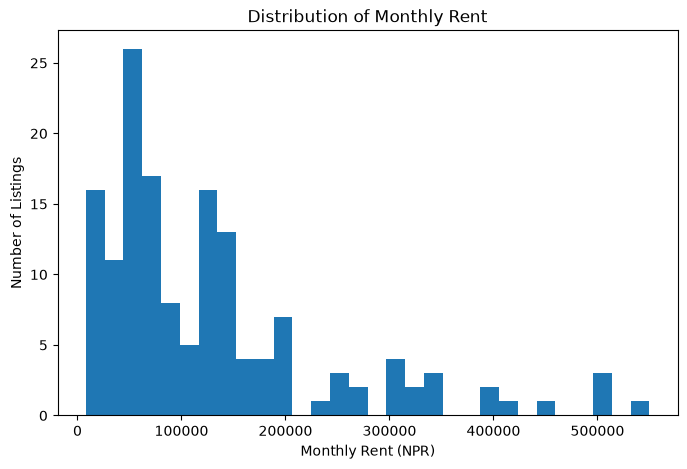

In [279]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_model["monthly_rent_npr"],
    bins=30
)

plt.xlabel("Monthly Rent (NPR)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Monthly Rent")

plt.show()

In [281]:
y_train_log = np.log1p(y_train)

In [283]:
results_log = []

for name, model in models.items():

    # Cross-validation
    cv_scores = cross_val_score(
        model,
        X_train_processed,
        y_train_log,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    # Train on log target
    model.fit(X_train_processed, y_train_log)

    # Predict log rent
    preds_log = model.predict(X_test_processed)

    # Convert predictions back to actual NPR
    preds = np.expm1(preds_log)

    results_log.append({
        "model": name,
        "cv_mae_log": -cv_scores.mean(),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_rmse": np.sqrt(
            mean_squared_error(y_test, preds)
        ),
        "test_r2": r2_score(y_test, preds)
    })

results_log_df = (
    pd.DataFrame(results_log)
    .sort_values("test_mae")
    .reset_index(drop=True)
)

print(results_log_df)

               model  cv_mae_log      test_mae      test_rmse   test_r2
0            XGBoost    0.461518  53906.280729   86358.755252  0.437480
1      Random Forest    0.418482  55661.284377   92894.713565  0.349110
2   Ridge Regression    0.495990  55925.909855   97639.339820  0.280923
3  Linear Regression    0.575088  68669.612811  112393.538862  0.047186
4      Decision Tree    0.598358  72231.595179  118627.211724 -0.061437
5      KNN Regressor    0.612488  76479.846099  115399.617842 -0.004464


In [285]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [287]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20).to_string(index=False))

                                         feature  importance
                              numeric__bathrooms    0.267210
                               numeric__bedrooms    0.177669
                       numeric__area_sqft_approx    0.153702
                         numeric__parking_spaces    0.116044
                            numeric__no_of_flats    0.031943
                          numeric__road_width_ft    0.029331
categorical__location_locality_clean_bishalnagar    0.022064
 categorical__location_locality_clean_mandikatar    0.019256
               categorical__direction_North East    0.019034
                           numeric__property_age    0.014087
                categorical__property_type_house    0.011346
                  categorical__direction_Unknown    0.010712
      categorical__location_locality_clean_Other    0.010688
                           categorical__ward_4.0    0.010112
                           categorical__ward_3.0    0.010020
                     num

In [297]:
# ============================================================
# TRANSFORM TEST DATA
# ============================================================

X_test_transformed = preprocessor.transform(X_test)

print("Original X_test shape:", X_test.shape)
print("Transformed X_test shape:", X_test_transformed.shape)

Original X_test shape: (30, 16)
Transformed X_test shape: (30, 73)


In [306]:
# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# Convert sparse matrix to dense NumPy array
if hasattr(X_test_transformed, "toarray"):
    X_test_perm = X_test_transformed.toarray()
else:
    X_test_perm = np.asarray(X_test_transformed)

print("X_test for permutation importance:", X_test_perm.shape)

# Calculate permutation importance
perm_result = permutation_importance(
    rf_model,
    X_test_perm,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Create dataframe
permutation_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

# Sort
permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

# Display top 20
print(permutation_importance_df.head(20).to_string(index=False))

X_test for permutation importance: (30, 73)
                                       feature  importance_mean  importance_std
                            numeric__bathrooms      9373.759550     4354.127487
                             numeric__bedrooms      4428.214317     2738.288081
                       numeric__parking_spaces      2323.985933     1527.568806
                   numeric__built_year_missing      1554.340867      629.813027
                         categorical__ward_3.0      1062.043883      477.670294
             categorical__direction_North East       906.949967      934.316811
                          numeric__no_of_flats       822.382867      973.951299
                         numeric__property_age       802.543933      974.174518
                        numeric__road_width_ft       757.435600     1094.734731
                         categorical__ward_4.0       723.133383      326.580628
categorical__location_locality_clean_lazimpath       556.116667       70.590

In [312]:
# ============================================================
# COMPARE BUILT-IN VS PERMUTATION IMPORTANCE
# ============================================================

comparison = pd.DataFrame({
    "feature": feature_names,
    "rf_importance": rf_model.feature_importances_,
    "permutation_importance": perm_result.importances_mean
})

comparison = comparison.sort_values(
    "permutation_importance",
    ascending=False
).reset_index(drop=True)

print(comparison.head(20).to_string(index=False))

                                       feature  rf_importance  permutation_importance
                            numeric__bathrooms       0.267210             9373.759550
                             numeric__bedrooms       0.177669             4428.214317
                       numeric__parking_spaces       0.116044             2323.985933
                   numeric__built_year_missing       0.008509             1554.340867
                         categorical__ward_3.0       0.010020             1062.043883
             categorical__direction_North East       0.019034              906.949967
                          numeric__no_of_flats       0.031943              822.382867
                         numeric__property_age       0.014087              802.543933
                        numeric__road_width_ft       0.029331              757.435600
                         categorical__ward_4.0       0.010112              723.133383
categorical__location_locality_clean_lazimpath       0

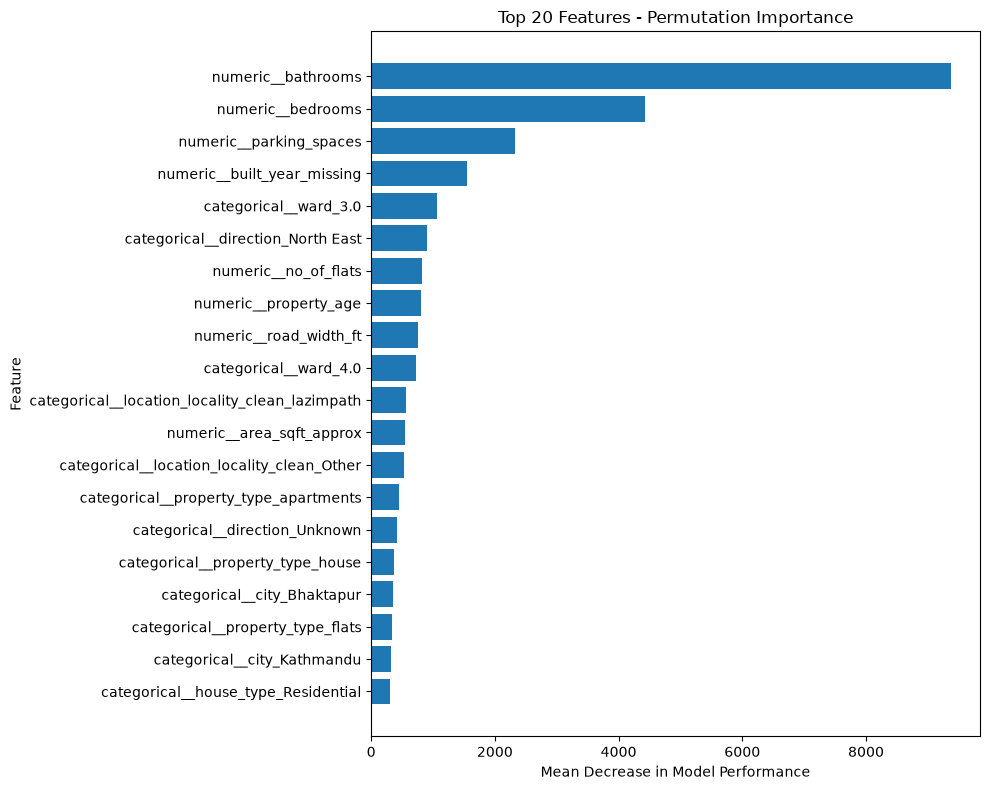

In [314]:
# ============================================================
# PERMUTATION IMPORTANCE PLOT
# ============================================================

top20 = permutation_importance_df.head(20).sort_values(
    "importance_mean"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["importance_mean"]
)

plt.xlabel("Mean Decrease in Model Performance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Permutation Importance")

plt.tight_layout()
plt.show()

In [316]:
# ============================================================
# CHECK BUILT YEAR MISSINGNESS
# ============================================================

print("Missing built_year:")
print(df["built_year"].isna().sum())

print("\nTotal rows:")
print(len(df))

print("\nMissing percentage:")
print(df["built_year"].isna().mean() * 100)

Missing built_year:
0

Total rows:
150

Missing percentage:
0.0


In [318]:
print(df.columns.tolist())

['listing_id', 'title', 'monthly_rent_npr', 'area_sqft_approx', 'road_width_ft', 'location', 'ward', 'municipality', 'property_type', 'house_type', 'direction', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'total_rooms', 'parking', 'built_up_sqft', 'no_of_flats', 'built_year', 'description', 'city', 'source', 'location_raw', 'location_numbers', 'number_matches_ward', 'location_clean', 'location_locality', 'location_last_number', 'location_locality_clean', 'text_for_rent_check', 'sale_in_text']


In [320]:
# Check the original built_year values
print(df["built_year"].value_counts(dropna=False).head(20))

# Check whether built_year_missing is actually constant
print("\nBuilt year missing indicator:")
print(df["built_year"].isna().value_counts())

built_year
Select Year    59
2076           18
2065           13
2066           13
2070            7
2075            6
2080            6
2081            6
2071            5
2078            4
2074            3
2067            3
2069            2
2072            1
2079            1
2077            1
2068            1
2082            1
Name: count, dtype: int64

Built year missing indicator:
built_year
False    150
Name: count, dtype: int64


In [322]:
# Convert invalid built_year value to NaN
df["built_year"] = df["built_year"].replace("Select Year", np.nan)

# Convert to numeric
df["built_year"] = pd.to_numeric(
    df["built_year"],
    errors="coerce"
)

# Check
print("Missing built_year:")
print(df["built_year"].isna().sum())

print("\nBuilt year values:")
print(df["built_year"].value_counts(dropna=False).head(20))

Missing built_year:
59

Built year values:
built_year
NaN       59
2076.0    18
2065.0    13
2066.0    13
2070.0     7
2075.0     6
2080.0     6
2081.0     6
2071.0     5
2078.0     4
2074.0     3
2067.0     3
2069.0     2
2072.0     1
2079.0     1
2077.0     1
2068.0     1
2082.0     1
Name: count, dtype: int64


In [324]:
# ============================================================
# 1. CLEAN BUILT YEAR
# ============================================================

import numpy as np
import pandas as pd

# Convert "Select Year" to missing
df["built_year"] = df["built_year"].replace("Select Year", np.nan)

# Convert to numeric
df["built_year"] = pd.to_numeric(
    df["built_year"],
    errors="coerce"
)

print("Missing built_year:", df["built_year"].isna().sum())

Missing built_year: 59


In [326]:
# ============================================================
# 2. BUILT YEAR MISSING INDICATOR
# ============================================================

df["built_year_missing"] = df["built_year"].isna().astype(int)

print(df["built_year_missing"].value_counts())

built_year_missing
0    91
1    59
Name: count, dtype: int64


In [328]:
# ============================================================
# 3. PROPERTY AGE
# ============================================================

CURRENT_BS_YEAR = 2083

df["property_age"] = np.where(
    df["built_year"].notna(),
    CURRENT_BS_YEAR - df["built_year"],
    np.nan
)

print(df[["built_year", "property_age"]].head(10))

   built_year  property_age
0      2072.0          11.0
1      2075.0           8.0
2      2070.0          13.0
3      2065.0          18.0
4         NaN           NaN
5      2065.0          18.0
6         NaN           NaN
7         NaN           NaN
8         NaN           NaN
9         NaN           NaN


In [330]:
# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

target = "monthly_rent_npr"

features = [
    "area_sqft_approx",
    "road_width_ft",
    "ward",
    "property_type",
    "house_type",
    "direction",
    "bedrooms",
    "bathrooms",
    "living_rooms",
    "kitchens",
    "total_rooms",
    "parking",
    "no_of_flats",
    "built_year",
    "built_year_missing",
    "property_age",
    "city",
    "location_locality_clean"
]

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 18)
y shape: (150,)


In [332]:
# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (120, 18)
Testing : (30, 18)


In [334]:
# ============================================================
# 6. NUMERICAL / CATEGORICAL FEATURES
# ============================================================

numeric_features = [
    "area_sqft_approx",
    "road_width_ft",
    "bedrooms",
    "bathrooms",
    "living_rooms",
    "kitchens",
    "total_rooms",
    "no_of_flats",
    "built_year",
    "built_year_missing",
    "property_age"
]

categorical_features = [
    "ward",
    "property_type",
    "house_type",
    "direction",
    "parking",
    "city",
    "location_locality_clean"
]

In [336]:
# ============================================================
# 7. PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [338]:
# ============================================================
# 8. TRANSFORM DATA
# ============================================================

X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print("Original X_train:", X_train.shape)
print("Transformed X_train:", X_train_transformed.shape)

print("Original X_test:", X_test.shape)
print("Transformed X_test:", X_test_transformed.shape)

Original X_train: (120, 18)
Transformed X_train: (120, 145)
Original X_test: (30, 18)
Transformed X_test: (30, 145)


In [340]:
# ============================================================
# 9. FEATURE NAMES AFTER PREPROCESSING
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of transformed features: 145

First 20 features:
['numeric__area_sqft_approx' 'numeric__road_width_ft' 'numeric__bedrooms'
 'numeric__bathrooms' 'numeric__living_rooms' 'numeric__kitchens'
 'numeric__total_rooms' 'numeric__no_of_flats' 'numeric__built_year'
 'numeric__built_year_missing' 'numeric__property_age'
 'categorical__ward_1.0' 'categorical__ward_2.0' 'categorical__ward_3.0'
 'categorical__ward_4.0' 'categorical__ward_5.0' 'categorical__ward_6.0'
 'categorical__ward_7.0' 'categorical__ward_8.0' 'categorical__ward_9.0']


In [342]:
# ============================================================
# 10. RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_transformed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [344]:
# ============================================================
# 11. RANDOM FOREST EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = rf_model.predict(X_test_transformed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Results
---------------------
MAE  : 55828.24
RMSE : 85164.65
R²   : 0.4529


In [346]:
# ============================================================
# 12. BUILT-IN FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20).to_string(index=False))

                                         feature  importance
                              numeric__bathrooms    0.254542
                               numeric__bedrooms    0.176158
                       numeric__area_sqft_approx    0.142948
                            numeric__total_rooms    0.121810
                 categorical__parking_Cars 10-15    0.034825
                            numeric__no_of_flats    0.028855
                          numeric__road_width_ft    0.021147
categorical__location_locality_clean_bishalnagar    0.015007
                categorical__property_type_house    0.010976
         categorical__house_type_Semi-commercial    0.010956
         categorical__direction_Select Direction    0.010268
                           numeric__property_age    0.009716
 categorical__location_locality_clean_mandikatar    0.009129
                           categorical__ward_4.0    0.008823
                             numeric__built_year    0.008245
                     num

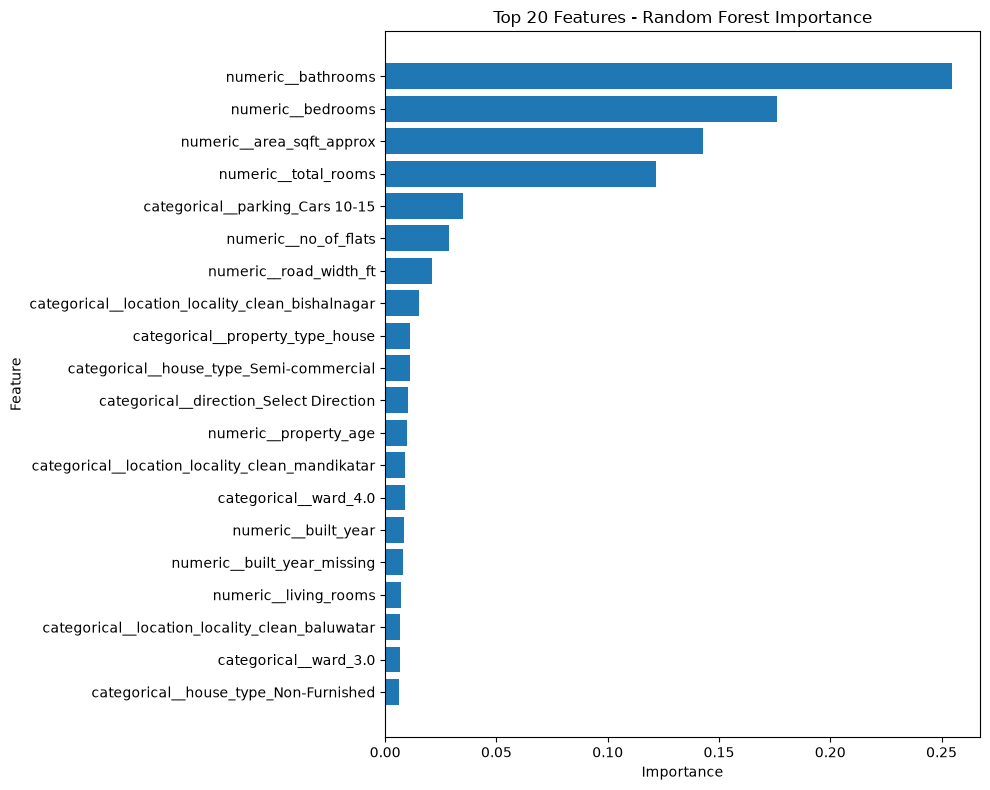

In [348]:
# ============================================================
# TOP 20 BUILT-IN FEATURE IMPORTANCE
# ============================================================

top20_rf = feature_importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_rf["feature"],
    top20_rf["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Random Forest Importance")

plt.tight_layout()
plt.show()

In [351]:
# ============================================================
# 13. PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

if hasattr(X_test_transformed, "toarray"):
    X_test_perm = X_test_transformed.toarray()
else:
    X_test_perm = np.asarray(X_test_transformed)

print("Permutation X_test shape:", X_test_perm.shape)

perm_result = permutation_importance(
    rf_model,
    X_test_perm,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    permutation_importance_df
    .head(20)
    .to_string(index=False)
)

Permutation X_test shape: (30, 145)
                                         feature  importance_mean  importance_std
                              numeric__bathrooms     10255.768200     4895.183779
                               numeric__bedrooms      5637.790850     2702.250679
                     numeric__built_year_missing      1704.675017      743.600470
                          numeric__road_width_ft       705.068450     1009.419893
                            numeric__no_of_flats       695.241067      820.474387
  categorical__location_locality_clean_lazimpath       670.400000       72.068763
           categorical__property_type_apartments       627.275600      335.495751
                           categorical__ward_3.0       600.833233      478.305108
                categorical__property_type_house       554.592900      384.552663
                           categorical__ward_4.0       551.658517      244.956952
                     categorical__city_Kathmandu       506.450

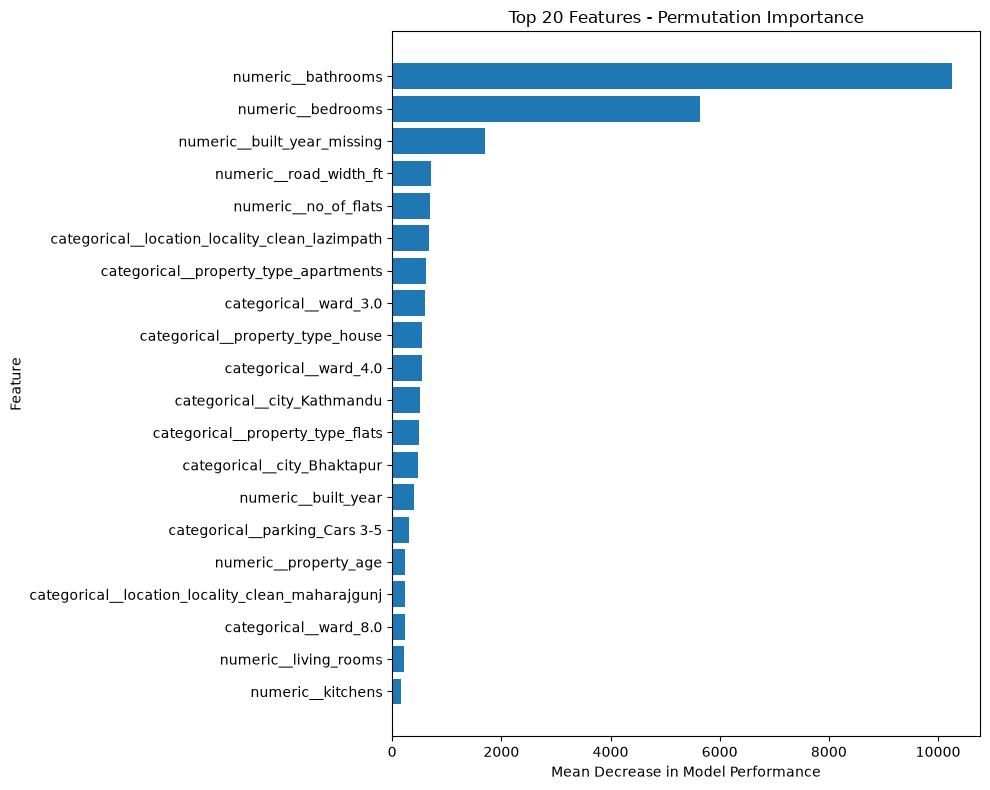

In [352]:
# ============================================================
# 14. PERMUTATION IMPORTANCE PLOT
# ============================================================

top20_perm = (
    permutation_importance_df
    .head(20)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_perm["feature"],
    top20_perm["importance_mean"]
)

plt.xlabel("Mean Decrease in Model Performance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Permutation Importance")

plt.tight_layout()
plt.show()

In [353]:
# ============================================================
# 15. COMPARE FEATURE IMPORTANCE
# ============================================================

comparison = pd.DataFrame({
    "feature": feature_names,
    "rf_importance": rf_model.feature_importances_,
    "permutation_importance": perm_result.importances_mean,
    "permutation_std": perm_result.importances_std
})

comparison = comparison.sort_values(
    "permutation_importance",
    ascending=False
).reset_index(drop=True)

print(
    comparison
    .head(25)
    .to_string(index=False)
)

                                         feature  rf_importance  permutation_importance  permutation_std
                              numeric__bathrooms       0.254542            10255.768200      4895.183779
                               numeric__bedrooms       0.176158             5637.790850      2702.250679
                     numeric__built_year_missing       0.007940             1704.675017       743.600470
                          numeric__road_width_ft       0.021147              705.068450      1009.419893
                            numeric__no_of_flats       0.028855              695.241067       820.474387
  categorical__location_locality_clean_lazimpath       0.000713              670.400000        72.068763
           categorical__property_type_apartments       0.003410              627.275600       335.495751
                           categorical__ward_3.0       0.006559              600.833233       478.305108
                categorical__property_type_house       

In [357]:
# ============================================================
# 16. RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.5, 0.7, 1.0]
}

rf_tuning = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuning.fit(
    X_train_transformed,
    y_train
)

print("Best parameters:")
print(rf_tuning.best_params_)

print("\nBest CV MAE:")
print(-rf_tuning.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}

Best CV MAE:
50173.147083333344


In [359]:
# ============================================================
# 17. FINAL TUNED RANDOM FOREST
# ============================================================

best_rf = rf_tuning.best_estimator_

y_pred_tuned = best_rf.predict(
    X_test_transformed
)

mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"MAE  : {mae_tuned:.2f}")
print(f"RMSE : {rmse_tuned:.2f}")
print(f"R²   : {r2_tuned:.4f}")

Tuned Random Forest Results
---------------------------
MAE  : 57302.66
RMSE : 87090.68
R²   : 0.4279


In [361]:
# ============================================================
# 18. BEFORE VS AFTER TUNING
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Random Forest - Baseline",
        "Random Forest - Tuned"
    ],
    "MAE": [
        mae,
        mae_tuned
    ],
    "RMSE": [
        rmse,
        rmse_tuned
    ],
    "R2": [
        r2,
        r2_tuned
    ]
})

print(results.to_string(index=False))

                   Model          MAE         RMSE       R2
Random Forest - Baseline 55828.240000 85164.654467 0.452928
   Random Forest - Tuned 57302.658667 87090.675344 0.427904
